# Oslo Bysykkel: Station Surplus/Deficit Mapping

Reads all 2025 trip data and (1) maps the average daily net bike flow per station,
and (2) tests a simple scaling method that estimates the daily surplus/deficit for
each station from a "global" daily trip forecast.

Per station, the net flow is computed as arrivals minus departures. Green stations accumulate bikes (must be transported away), red stations drain bikes (must be restocked). 

**Mapping method:**
1. Derive each station's *mean* daily net flow from the full 2025 data.
2. For each day compute a *daily factor* = no. actual trips / no. mean daily trips.
3. Estimated net flow for station *s* on day *d* =
   `mean_daily_net_flow(s) × daily_factor(d)`
4. Compare against the *observed* daily net flow per station for validation.

Eventual goal: we can use this mapping to translate forecasted **global** trips to estimated bike surplus/deficit **per station**, on a daily basis. 

**Input:** `input/turdata/2025/*.csv`  
**Output:** `output/station_surplus_deficit.html`, `output/station_surplus_deficit.png`,
`output/station_daily_forecast_2025.csv`, `output/station_forecast_quality_2025.csv`

## 0 · Imports & config

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, r2_score

TURDATA_DIR  = Path("input/turdata/2025")
OUTPUT_DIR   = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

CLOSED_HOURS = [1, 2, 3, 4]   # 01:00–04:59 Oslo time — service closure
N_DAYS       = 365            # 2025 is not a leap year

## 1 · Load 2025 trip data

In [2]:
COLS = [
    "started_at",
    "start_station_id", "start_station_name",
    "start_station_latitude", "start_station_longitude",
    "end_station_id",   "end_station_name",
    "end_station_latitude",   "end_station_longitude",
]

frames = []
for path in sorted(TURDATA_DIR.glob("*.csv")):
    chunk = pd.read_csv(path, usecols=COLS, low_memory=False)
    frames.append(chunk)
    print(f"  {path.name}  {len(chunk):>8,} trips")

trips = pd.concat(frames, ignore_index=True)

# Drop rows with missing station info
trips = trips.dropna(subset=[
    "start_station_id", "end_station_id",
    "start_station_latitude", "end_station_latitude",
])
trips["start_station_id"] = trips["start_station_id"].astype(int)
trips["end_station_id"]   = trips["end_station_id"].astype(int)

# Parse trip start time in Oslo local time
trips["_started_oslo"] = (
    pd.to_datetime(trips["started_at"], format="ISO8601", utc=True)
    .dt.tz_convert("Europe/Oslo")
)

# Exclude service closure hours (01:00–04:59 Oslo time — no trips possible)
before = len(trips)
trips = trips[~trips["_started_oslo"].dt.hour.isin(CLOSED_HOURS)].copy()
print(f"Dropped {before - len(trips):,} closure-hour rows  ({len(trips):,} remaining)")

# Service day: 05:00 on day D through 00:00 on day D+1 — shift back 5 hours
trips["date"] = (
    (trips["_started_oslo"] - pd.Timedelta(hours=5))
    .dt.normalize()
    .dt.tz_localize(None)
)
trips = trips.drop(columns=["_started_oslo"])

print(f"\nTotal trips : {len(trips):,}")
print(f"Date range  : {trips['date'].min().date()} → {trips['date'].max().date()}")

  01.csv    10,355 trips
  02.csv    15,486 trips
  03.csv    42,990 trips
  04.csv    98,165 trips
  05.csv   143,534 trips
  06.csv   149,077 trips
  07.csv   145,568 trips
  08.csv   176,415 trips
  09.csv   138,416 trips
  10.csv   105,957 trips
  11.csv    63,624 trips
  12.csv    23,717 trips
Dropped 26 closure-hour rows  (1,113,278 remaining)

Total trips : 1,113,278
Date range  : 2025-01-01 → 2025-12-31


## 2 · Per-station annual net flow

In [3]:
dep_annual = (
    trips.groupby("start_station_id")
    .agg(
        departures_annual = ("start_station_id",       "count"),
        name              = ("start_station_name",      "first"),
        lat               = ("start_station_latitude",  "first"),
        lon               = ("start_station_longitude", "first"),
    )
    .rename_axis("station_id")
)

arr_annual = (
    trips.groupby("end_station_id")
    .agg(
        arrivals_annual   = ("end_station_id",         "count"),
        name_end          = ("end_station_name",        "first"),
        lat_end           = ("end_station_latitude",    "first"),
        lon_end           = ("end_station_longitude",   "first"),
    )
    .rename_axis("station_id")
)

stations = dep_annual.join(arr_annual, how="outer").fillna(0)

# Resolve coordinates: prefer departure-side (larger sample for most stations)
stations["lat"]  = stations["lat"].where(stations["lat"]  != 0, stations["lat_end"])
stations["lon"]  = stations["lon"].where(stations["lon"]  != 0, stations["lon_end"])
stations["name"] = stations["name"].where(stations["name"] != 0, stations["name_end"])
stations = stations.drop(columns=["lat_end", "lon_end", "name_end"])
stations = stations[(stations["lat"] != 0) & (stations["lon"] != 0)]

stations["net_flow_annual"]     = stations["arrivals_annual"] - stations["departures_annual"]
stations["mean_daily_net_flow"] = stations["net_flow_annual"] / N_DAYS

print(f"Stations: {len(stations)}")
print(f"\nAnnual totals \u2014 arrivals: {stations['arrivals_annual'].sum():,}  "
      f"departures: {stations['departures_annual'].sum():,}")
print(f"\nTop 10 surplus stations (bikes accumulate):")
print(stations.nlargest(10, "mean_daily_net_flow")[["name", "mean_daily_net_flow"]].to_string())
print(f"\nTop 10 deficit stations (bikes drain away):")
print(stations.nsmallest(10, "mean_daily_net_flow")[["name", "mean_daily_net_flow"]].to_string())

Stations: 272

Annual totals — arrivals: 1,113,278  departures: 1,113,278

Top 10 surplus stations (bikes accumulate):
                                        name  mean_daily_net_flow
station_id                                                       
523                              Tøyenbekken            19.597260
2328                                 The Hub            17.756164
489                                 Torggata            17.684932
495                         Vaterlandsparken            16.054795
611                              Bankplassen            13.515068
396                              Kirkeristen            13.509589
1755        Aker Brygge 1 mot Nasjonalmuseet            13.498630
465                                 Bjørvika            12.865753
430                         Spikersuppa Vest            12.213699
480                    Helga Helgesens plass            11.786301

Top 10 deficit stations (bikes drain away):
                                 name  mean_

## 3 · Surplus / deficit map

In [ ]:
# ── colour scale ─────────────────────────────────────────────────────────────
# Symmetric cap at the 95th percentile of absolute daily net flow
cap     = np.percentile(np.abs(stations["mean_daily_net_flow"]), 95)
clamped = stations["mean_daily_net_flow"].clip(-cap, cap)

# Marker size: proportional to |net flow|, with a floor so every station is visible
max_size = 28
min_size = 5
sizes = min_size + (max_size - min_size) * (np.abs(clamped) / cap)

# ── hover text ───────────────────────────────────────────────────────────────
hover = [
    f"<b>{row['name']}</b><br>"
    f"Daily net flow: {row['mean_daily_net_flow']:+.1f} bikes/day<br>"
    f"2025 arrivals: {int(row['arrivals_annual']):,}  |  departures: {int(row['departures_annual']):,}"
    for _, row in stations.iterrows()
]

# ── build figure ─────────────────────────────────────────────────────────────
fig_map = go.Figure()

fig_map.add_trace(go.Scattermap(
    lat    = stations["lat"],
    lon    = stations["lon"],
    mode   = "markers",
    marker = dict(
        size        = sizes,
        color       = stations["mean_daily_net_flow"],
        colorscale  = [
            [0.0,  "rgb(220,60,60)"],
            [0.5,  "rgb(240,240,240)"],
            [1.0,  "rgb(60,180,60)"],
        ],
        cmin        = -cap,
        cmax        =  cap,
        colorbar    = dict(
            title       = "Bikes / day",
            tickformat  = "+.0f",
            thickness   = 14,
            len         = 0.6,
        ),
        opacity     = 0.88,
    ),
    text      = hover,
    hoverinfo = "text",
))

fig_map.update_layout(
    map = dict(
        style  = "carto-positron",
        center = dict(lat=59.925, lon=10.745),
        zoom   = 12.3,
    ),
    title = dict(
        text     = "Oslo Bysykkel \u2014 average daily net bike flow per station (2025)",
        font     = dict(size=15),
        x        = 0.5,
        xanchor  = "center",
    ),
    annotations = [
        dict(
            text       = "<b style='color:rgb(60,180,60)'>Green</b> = surplus (bikes accumulate)  "
                         "<b style='color:rgb(220,60,60)'>Red</b> = deficit (bikes drain away)",
            showarrow  = False,
            xref="paper", yref="paper",
            x=0.5, y=-0.04,
            font=dict(size=11),
            align="center",
        )
    ],
    margin = dict(l=0, r=0, t=50, b=50),
    height = 700,
)

fig_map.show()

## 4 · Summary statistics

In [15]:
n_surplus = (stations["mean_daily_net_flow"] >  1).sum()
n_deficit = (stations["mean_daily_net_flow"] < -1).sum()
n_neutral = len(stations) - n_surplus - n_deficit

total_rebalancing = stations["mean_daily_net_flow"].clip(lower=0).sum()

print(f"Surplus stations (> +1 bike/day) : {n_surplus}")
print(f"Deficit stations (< -1 bike/day) : {n_deficit}")
print(f"Near-neutral                     : {n_neutral}")
print()
print(f"Minimum daily rebalancing load   : ~{total_rebalancing:.0f} bike movements/day (2025 average)")
print(f"(sum of all surplus flows, i.e. how many bikes must be transported each day)")

Surplus stations (> +1 bike/day) : 54
Deficit stations (< -1 bike/day) : 81
Near-neutral                     : 137

Minimum daily rebalancing load   : ~374 bike movements/day (2025 average)
(sum of all surplus flows, i.e. how many bikes must be transported each day)


## 5 · Daily system totals & daily factor

The daily factor tells us how busy a given day was relative to the average day in 2025.
Example: a factor of 1.5 means 50% more trips than the average day. Factors > 1 are busy days, factors < 1 are quiet days when compared to the average day. 

Total 2025 trips  : 1,113,278
Mean daily trips  : 3,050.1
Daily factor range: 0.019 → 2.511


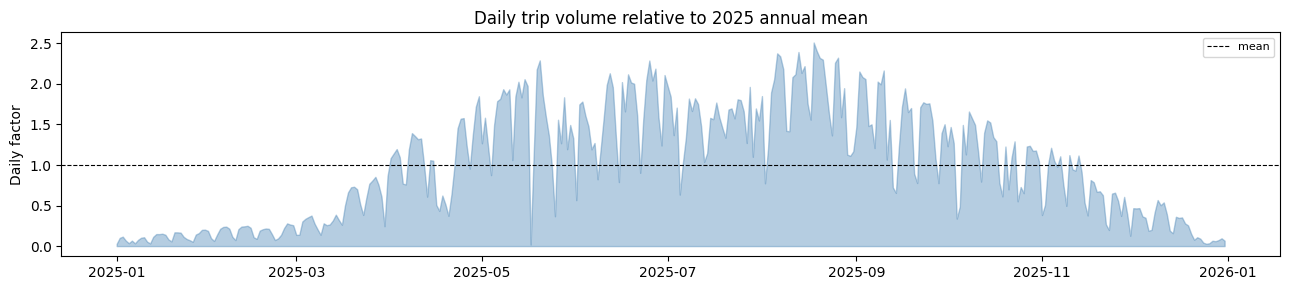

In [6]:
daily_trips = (
    trips.groupby("date").size()
    .rename("total_trips")
    .reset_index()
    .sort_values("date")
)

mean_daily_trips = daily_trips["total_trips"].mean()
daily_trips["daily_factor"] = daily_trips["total_trips"] / mean_daily_trips

print(f"Total 2025 trips  : {daily_trips['total_trips'].sum():,}")
print(f"Mean daily trips  : {mean_daily_trips:,.1f}")
print(f"Daily factor range: {daily_trips['daily_factor'].min():.3f} \u2192 {daily_trips['daily_factor'].max():.3f}")

fig, ax = plt.subplots(figsize=(13, 3))
ax.fill_between(daily_trips["date"], daily_trips["daily_factor"], alpha=0.4, color="steelblue")
ax.axhline(1, color="k", lw=0.8, ls="--", label="mean")
ax.set_ylabel("Daily factor")
ax.set_title("Daily trip volume relative to 2025 annual mean")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6 · Observed daily net flow per station

Actual daily arrivals minus departures for every (station, date) pair, based on the provided trip data. 

In [7]:
# Daily departures per station
dep_daily = (
    trips.groupby(["date", "start_station_id"]).size()
    .rename("departures")
    .reset_index()
    .rename(columns={"start_station_id": "station_id"})
)

# Daily arrivals per station
arr_daily = (
    trips.groupby(["date", "end_station_id"]).size()
    .rename("arrivals")
    .reset_index()
    .rename(columns={"end_station_id": "station_id"})
)

obs = pd.merge(dep_daily, arr_daily, on=["date", "station_id"], how="outer").fillna(0)
obs["observed_net_flow"] = obs["arrivals"] - obs["departures"]

# Keep only stations in our annual station table
obs = obs[obs["station_id"].isin(stations.index)]

print(f"Observation rows (station \u00d7 day): {len(obs):,}")
print(f"Unique stations in daily obs    : {obs['station_id'].nunique()}")
print(f"Date range                      : {obs['date'].min().date()} \u2192 {obs['date'].max().date()}")

Observation rows (station × day): 83,753
Unique stations in daily obs    : 272
Date range                      : 2025-01-01 → 2025-12-31


## 7 · Estimated daily net flow (mapping method)

For each (station, day):

```
estimated_net_flow(s, d) = mean_daily_net_flow(s) × daily_factor(d)
```

In [8]:
# Join daily factor onto observation table
obs = obs.merge(daily_trips[["date", "daily_factor"]], on="date", how="left")

# Join mean_daily_net_flow from annual station table
obs = obs.merge(
    stations[["mean_daily_net_flow"]],
    left_on="station_id", right_index=True,
    how="left",
)

obs["estimated_net_flow"] = obs["mean_daily_net_flow"] * obs["daily_factor"]

obs = obs.sort_values(["station_id", "date"]).reset_index(drop=True)

print(obs[["date", "station_id", "observed_net_flow", "estimated_net_flow",
           "daily_factor", "mean_daily_net_flow"]].head(10).to_string(index=False))

      date  station_id  observed_net_flow  estimated_net_flow  daily_factor  mean_daily_net_flow
2025-04-30         377                1.0           -1.625360      1.848150            -0.879452
2025-05-01         377                1.0           -1.115290      1.268165            -0.879452
2025-05-02         377                1.0           -1.392383      1.583239            -0.879452
2025-05-03         377                0.0           -1.083573      1.232100            -0.879452
2025-05-04         377               -3.0           -0.769862      0.875388            -0.879452
2025-05-05         377                1.0           -1.315973      1.496356            -0.879452
2025-05-06         377               -1.0           -1.571729      1.787168            -0.879452
2025-05-07         377                2.0           -1.597679      1.816676            -0.879452
2025-05-08         377              -12.0           -1.701769      1.935033            -0.879452
2025-05-09         377        

## 8 · Validation

### 8a · Overall metrics

In [16]:
y_obs = obs["observed_net_flow"].values
y_est = obs["estimated_net_flow"].values

mae  = mean_absolute_error(y_obs, y_est)
r2   = r2_score(y_obs, y_est)
bias = (y_est - y_obs).mean()
corr = np.corrcoef(y_obs, y_est)[0, 1]

print(f"Overall (all stations \u00d7 all days)")
print(f"  MAE  : {mae:.2f} bikes/day")
print(f"  R\u00b2   : {r2:.3f}")
print(f"  Corr : {corr:.3f}")
print(f"  Bias : {bias:+.3f} (mean over/under-estimate)")

Overall (all stations × all days)
  MAE  : 3.42 bikes/day
  R²   : 0.611
  Corr : 0.784
  Bias : +0.054 (mean over/under-estimate)


### 8b · Scatter: estimated vs. observed (random sample of 10 000 points)

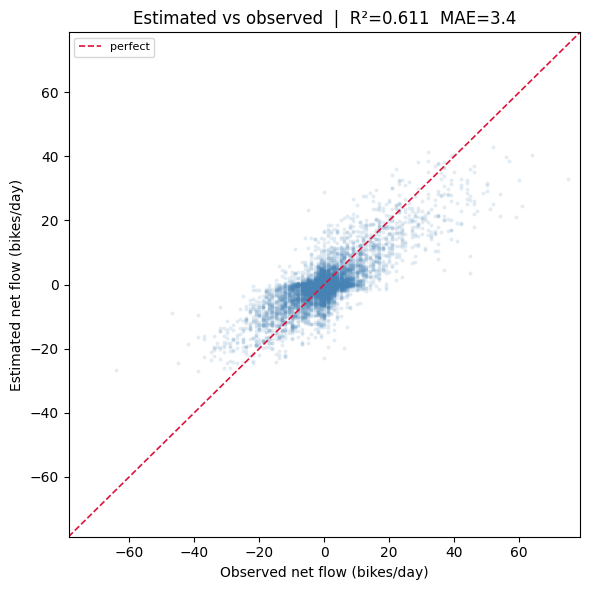

In [17]:
rng   = np.random.default_rng(42)
idx   = rng.choice(len(obs), size=min(10_000, len(obs)), replace=False)
s_obs = y_obs[idx]
s_est = y_est[idx]

lim = max(np.abs(s_obs).max(), np.abs(s_est).max()) * 1.05

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(s_obs, s_est, alpha=0.15, s=8, color="steelblue", linewidths=0)
ax.axline((0, 0), slope=1, color="crimson", lw=1.2, ls="--", label="perfect")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("Observed net flow (bikes/day)")
ax.set_ylabel("Estimated net flow (bikes/day)")
ax.set_title(f"Estimated vs observed  |  R\u00b2={r2:.3f}  MAE={mae:.1f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

From looking at the metrics and scatter plot: good correlation between estimated and observed net flow (expected), but significant daily errors remain. 

### 8c · Per-station R²

For each station we compute R² between its 365-day estimated and observed series.
This allows us to check how well the method works per station. 

Stations with R² > 0.5 : 20
Stations with R² > 0.3 : 51
Stations with R² ≤ 0   : 51

Median station R²      : 0.021
Median station MAE     : 2.96 bikes/day


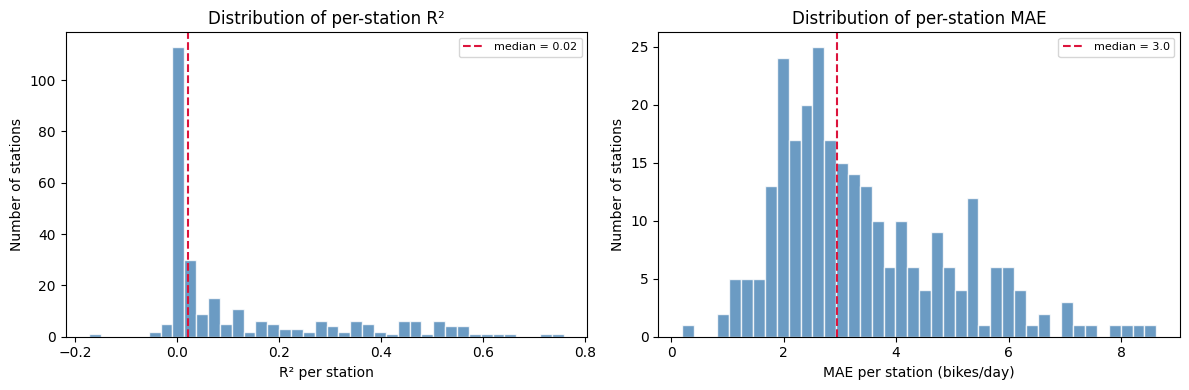

In [11]:
def station_r2(grp):
    # R² is undefined (and uninteresting) for stations with zero variance in observed flow
    if grp["observed_net_flow"].std() < 0.5:
        return np.nan
    return r2_score(grp["observed_net_flow"], grp["estimated_net_flow"])

station_r2_series  = obs.groupby("station_id").apply(station_r2).rename("r2")
station_mae_series = (
    obs.groupby("station_id")
    .apply(lambda g: mean_absolute_error(g["observed_net_flow"], g["estimated_net_flow"]))
    .rename("mae")
)

per_station = stations[["name", "mean_daily_net_flow", "lat", "lon"]].join(station_r2_series).join(station_mae_series)

print(f"Stations with R\u00b2 > 0.5 : {(per_station['r2'] > 0.5).sum()}")
print(f"Stations with R\u00b2 > 0.3 : {(per_station['r2'] > 0.3).sum()}")
print(f"Stations with R\u00b2 \u2264 0   : {(per_station['r2'] <= 0).sum()}")
print(f"\nMedian station R\u00b2      : {per_station['r2'].median():.3f}")
print(f"Median station MAE     : {per_station['mae'].median():.2f} bikes/day")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_station["r2"].dropna(), bins=40, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(per_station["r2"].median(), color="crimson", lw=1.5, ls="--",
                label=f"median = {per_station['r2'].median():.2f}")
axes[0].set_xlabel("R\u00b2 per station")
axes[0].set_ylabel("Number of stations")
axes[0].set_title("Distribution of per-station R\u00b2")
axes[0].legend(fontsize=8)

axes[1].hist(per_station["mae"].dropna(), bins=40, color="steelblue", alpha=0.8, edgecolor="white")
axes[1].axvline(per_station["mae"].median(), color="crimson", lw=1.5, ls="--",
                label=f"median = {per_station['mae'].median():.1f}")
axes[1].set_xlabel("MAE per station (bikes/day)")
axes[1].set_ylabel("Number of stations")
axes[1].set_title("Distribution of per-station MAE")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

The mapping model seems to work decently for some stations (R² closer to 1), while there is a subset of stations for which the mapping does not work well (low or even negative R², see the spike in stations at R²~0). Suspicion: this method works OK for larger stations with a consistent deficit or surplus, while numbers for more variable stations (sometimes a surplus, sometimes a deficit) are more difficult to estimate. 

### 8d · Worst and best stations

Looking at the best and worst fitting stations helps diagnose whether there are
systematic patterns the method misses. 

In [12]:
print("Best-fit stations (highest R\u00b2):")
print(per_station.nlargest(8, "r2")[["name", "r2", "mae", "mean_daily_net_flow"]].to_string())
print()
print("Worst-fit stations (lowest R\u00b2, min 50 obs days):")
active     = obs.groupby("station_id").size()
active_ids = active[active >= 50].index
print(per_station.loc[per_station.index.isin(active_ids)]
      .nsmallest(8, "r2")[["name", "r2", "mae", "mean_daily_net_flow"]].to_string())

Best-fit stations (highest R²):
                                        name        r2       mae  mean_daily_net_flow
station_id                                                                           
523                              Tøyenbekken  0.758654  7.014046            19.597260
495                         Vaterlandsparken  0.716345  6.096932            16.054795
465                                 Bjørvika  0.649396  5.911221            12.865753
2328                                 The Hub  0.627718  8.081484            17.756164
1755        Aker Brygge 1 mot Nasjonalmuseet  0.609608  6.303243            13.498630
489                                 Torggata  0.584124  8.268120            17.684932
577                             Arkaden Nord  0.570597  4.935998             9.589041
430                         Spikersuppa Vest  0.564397  7.131651            12.213699

Worst-fit stations (lowest R², min 50 obs days):
                               name        r2       mae  m

### 8e · Time series for selected stations

The single largest surplus and deficit station by annual net flow, plus the
median-R² station, plotted across the full year.

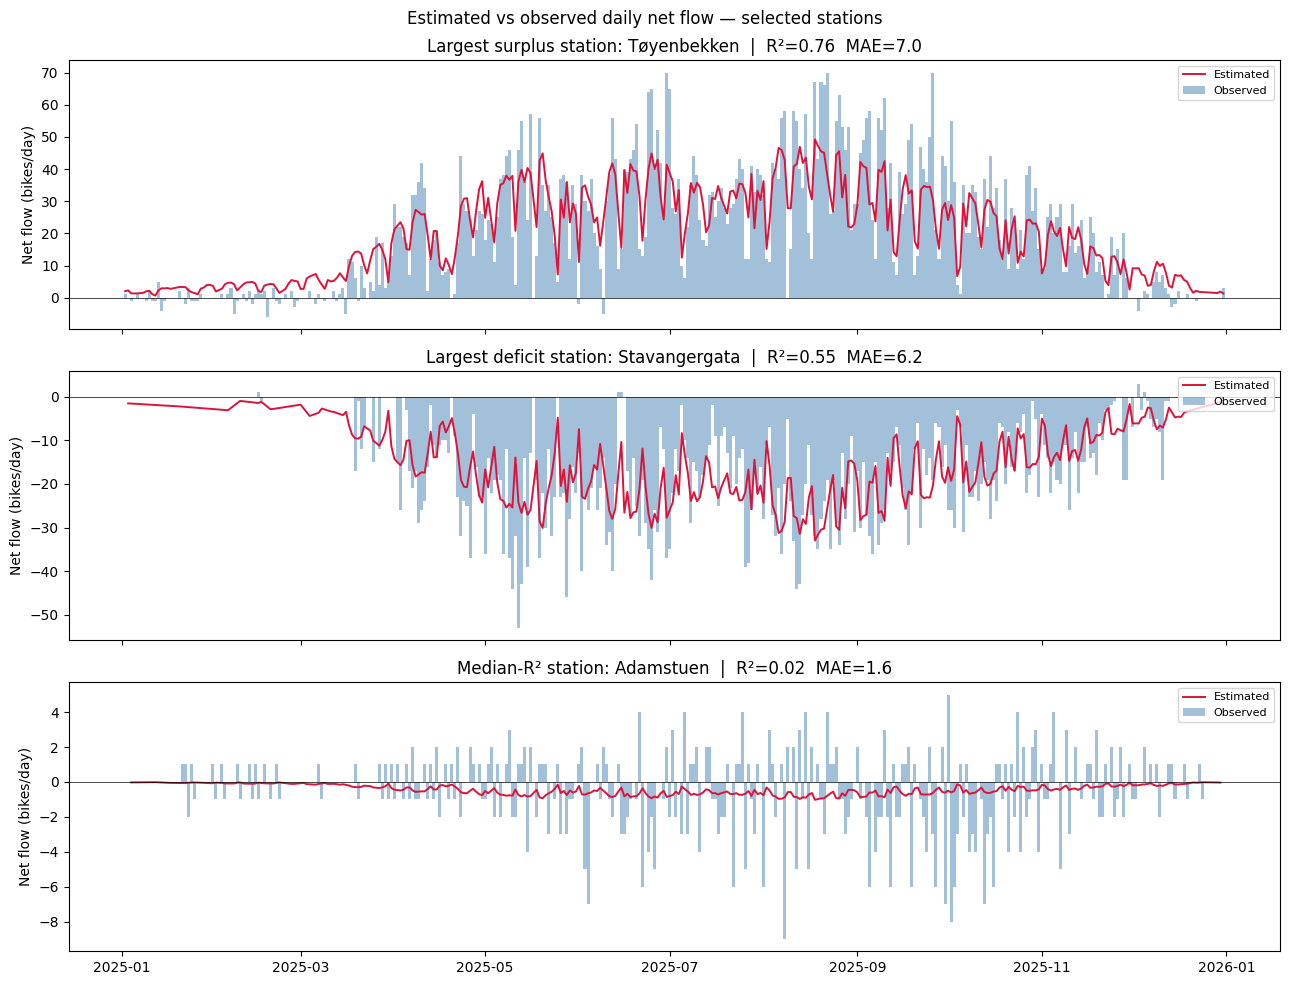

In [13]:
top_surplus = per_station["mean_daily_net_flow"].idxmax()
top_deficit = per_station["mean_daily_net_flow"].idxmin()
median_idx  = (per_station["r2"] - per_station["r2"].median()).abs().idxmin()

showcase = [
    (top_surplus, "Largest surplus station"),
    (top_deficit, "Largest deficit station"),
    (median_idx,  "Median-R\u00b2 station"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (sid, label) in zip(axes, showcase):
    sub     = obs[obs["station_id"] == sid].sort_values("date")
    r2_val  = per_station.loc[sid, "r2"]
    mae_val = per_station.loc[sid, "mae"]
    name    = per_station.loc[sid, "name"]

    ax.bar(sub["date"], sub["observed_net_flow"],
           width=1, alpha=0.5, color="steelblue", label="Observed")
    ax.plot(sub["date"], sub["estimated_net_flow"],
            color="crimson", lw=1.4, label="Estimated")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("Net flow (bikes/day)")
    ax.set_title(f"{label}: {name}  |  R\u00b2={r2_val:.2f}  MAE={mae_val:.1f}")
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Estimated vs observed daily net flow \u2014 selected stations", fontsize=12)
plt.tight_layout()
plt.show()

As hypothesized above: the "problem stations" appear to be the smaller, more balanced stations with a less clear surplus or deficit signal, while estimates for the bigger clearly unbalanced stations track reasonably well with observations. Maybe the smaller variable stations have more distinct week day/weekend patterns we could use to improve estimates? To explored further at a later date. 

## 9 · Save outputs

In [ ]:
# Surplus/deficit map
html_path = OUTPUT_DIR / "station_surplus_deficit.html"
fig_map.write_html(str(html_path))
print(f"Saved interactive map \u2192 {html_path.resolve()}")

try:
    png_path = OUTPUT_DIR / "station_surplus_deficit.png"
    fig_map.write_image(str(png_path), width=1350, height=900, scale=2)
    print(f"Saved static PNG      \u2192 {png_path.resolve()}")
except Exception as e:
    print(f"PNG export skipped ({e})")
    print("  \u2192 install kaleido:  pip install kaleido")

# Per-station daily forecast data
out_path = OUTPUT_DIR / "station_daily_forecast_2025.csv"
obs[["date", "station_id", "departures", "arrivals",
     "observed_net_flow", "daily_factor", "mean_daily_net_flow",
     "estimated_net_flow"]].to_csv(out_path, index=False)
print(f"Saved \u2192 {out_path.resolve()}")

# Per-station quality summary
qual_path = OUTPUT_DIR / "station_forecast_quality_2025.csv"
per_station.reset_index().rename(columns={"index": "station_id"}).to_csv(qual_path, index=False)
print(f"Saved \u2192 {qual_path.resolve()}")